

> # NHS A&E Attendance Analysis — Winter Pressure & Trust Performance

**Dataset:** NHS England official A&E Attendances and Emergency Admissions data
(Oct 2025 – Mar 2026, 6 months, all NHS Trusts/providers in England)

**Source:** https://www.england.nhs.uk/statistics/statistical-work-areas/ae-waiting-times-and-activity/

**Why this dataset:** Chosen for direct relevance to Digiryte's client work with the NHS —
this is the same kind of real, operational public-sector data the company's healthcare
projects deal with, rather than a generic Kaggle dataset.

This notebook combines 6 monthly CSVs, cleans known data quality issues, and presents
3 findings on A&E performance.



In [1]:
import pandas as pd
import glob

files = glob.glob("*.csv")
print("Found files:", files)

for f in files:
    df = pd.read_csv(f)
    print(f"\n{f} -> shape: {df.shape}")
    print(df.columns.tolist())

Found files: ['February-2026-CSV-Dl8t54.csv', 'Monthly-AE-March-2026-revised-flkg42.csv', 'Monthly-AE-October-2025-revised-fly02sk.csv', 'Monthly-AE-December-2025-revised-g9Hy6.csv', 'Monthly-AE-January-2026-revised-3dker.csv', 'Monthly-AE-Nov-25-CSV-revised.csv']

February-2026-CSV-Dl8t54.csv -> shape: (198, 22)
['Period', 'Org Code', 'Parent Org', 'Org name', 'A&E attendances Type 1', 'A&E attendances Type 2', 'A&E attendances Other A&E Department', 'A&E attendances Booked Appointments Type 1', 'A&E attendances Booked Appointments Type 2', 'A&E attendances Booked Appointments Other Department', 'Attendances over 4hrs Type 1', 'Attendances over 4hrs Type 2', 'Attendances over 4hrs Other Department', 'Attendances over 4hrs Booked Appointments Type 1', 'Attendances over 4hrs Booked Appointments Type 2', 'Attendances over 4hrs Booked Appointments Other Department', 'Patients who have waited 4-12 hs from DTA to admission', 'Patients who have waited 12+ hrs from DTA to admission', 'Emergen

## Data Cleaning

The raw files contained two separate issues that needed handling:
1. Each month included a `Period == "TOTAL"` summary row that needed removal
2. February's file additionally had an `Org Code == "TOTAL"` national rollup row
   with no matching Period flag — this was caught because February's national
   attendance figure looked nearly double every other month, and traced back to
   this row.

Both were removed. No other missing values or duplicates were found in the cleaned data.

In [2]:
import pandas as pd
import glob
import re

files = glob.glob("*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    # Pull month-year from filename to tag each row
    match = re.search(r'(January|February|March|April|May|June|July|August|September|October|November|December)[-_]?(\d{4})', f)
    df["source_month"] = f"{match.group(1)} {match.group(2)}" if match else f
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
print("Combined shape:", combined.shape)

# Show full column list (not truncated)
for col in combined.columns:
    print(col)

Combined shape: (1190, 23)
Period
Org Code
Parent Org
Org name
A&E attendances Type 1
A&E attendances Type 2
A&E attendances Other A&E Department
A&E attendances Booked Appointments Type 1
A&E attendances Booked Appointments Type 2
A&E attendances Booked Appointments Other Department
Attendances over 4hrs Type 1
Attendances over 4hrs Type 2
Attendances over 4hrs Other Department
Attendances over 4hrs Booked Appointments Type 1
Attendances over 4hrs Booked Appointments Type 2
Attendances over 4hrs Booked Appointments Other Department
Patients who have waited 4-12 hs from DTA to admission
Patients who have waited 12+ hrs from DTA to admission
Emergency admissions via A&E - Type 1
Emergency admissions via A&E - Type 2
Emergency admissions via A&E - Other A&E department
Other emergency admissions
source_month


In [3]:
# Check data types - numeric columns should NOT show up as 'object'
print(combined.dtypes)

print("\nMissing values per column:")
print(combined.isna().sum()[combined.isna().sum() > 0])

print("\nSample of a numeric-looking column:")
print(combined["A&E attendances Type 1"].head())

Period                                                        object
Org Code                                                      object
Parent Org                                                    object
Org name                                                      object
A&E attendances Type 1                                         int64
A&E attendances Type 2                                         int64
A&E attendances Other A&E Department                           int64
A&E attendances Booked Appointments Type 1                     int64
A&E attendances Booked Appointments Type 2                     int64
A&E attendances Booked Appointments Other Department           int64
Attendances over 4hrs Type 1                                   int64
Attendances over 4hrs Type 2                                   int64
Attendances over 4hrs Other Department                         int64
Attendances over 4hrs Booked Appointments Type 1               int64
Attendances over 4hrs Booked Appoi

In [4]:
# 1. Check the Period column format - is it usable as a date?
print("Period samples:", combined["Period"].unique()[:5])

# 2. Check for duplicate rows (same org, same period appearing twice)
dupes = combined.duplicated(subset=["Org Code", "Period"], keep=False)
print("\nDuplicate org+period rows:", dupes.sum())

# 3. Check if every org appears in all 6 months (or if some orgs are missing/inconsistent)
org_counts = combined.groupby("Org Code")["Period"].count()
print("\nOrgs NOT present in all 6 months:")
print(org_counts[org_counts < 6])

# 4. Check for suspicious zero values (could be real, could be non-reporting)
zero_check = (combined["A&E attendances Type 1"] == 0).sum()
print(f"\nRows where A&E attendances Type 1 = 0: {zero_check}")

# 5. Look at Org name for inconsistent naming (trailing spaces, case differences)
print("\nSample org names:")
print(combined["Org name"].unique()[:10])

Period samples: ['MSitAE-FEBRUARY-2026' 'MSitAE-MARCH-2026' 'TOTAL' 'MSitAE-OCTOBER-2025'
 'MSitAE-DECEMBER-2025']

Duplicate org+period rows: 5

Orgs NOT present in all 6 months:
Org Code
NNJ10    1
NNJ11    1
Name: Period, dtype: int64

Rows where A&E attendances Type 1 = 0: 458

Sample org names:
['BRIGHTON STATION HEALTH CENTRE' 'TETBURY HOSPITAL TRUST LTD'
 'WORKINGTON HEALTH LIMITED' 'LATHAM HOUSE MEDICAL PRACTICE'
 'SLEAFORD MEDICAL GROUP' 'HERNE BAY HEALTH CARE LTD'
 'FIRST COMMUNITY HEALTH AND CARE CIC' 'SKELMERSDALE WALK IN CENTRE'
 'ASHFORD WALK-IN-CENTRE' 'WOKING WALK IN CENTRE']


In [5]:
# Remove the 'TOTAL' summary row(s) - keep only real organisations
print("Unique Org Codes containing TOTAL-like entries:")
print(combined[combined["Period"] == "TOTAL"]["Org Code"].unique())

cleaned = combined[combined["Period"] != "TOTAL"].copy()
print("\nShape before:", combined.shape, "-> after removing TOTAL rows:", cleaned.shape)

# Re-check duplicates on the cleaned data
dupes_cleaned = cleaned.duplicated(subset=["Org Code", "Period"], keep=False)
print("\nDuplicate org+period rows after cleaning:", dupes_cleaned.sum())
if dupes_cleaned.sum() > 0:
    print(cleaned[dupes_cleaned][["Org Code", "Org name", "Period"]])

Unique Org Codes containing TOTAL-like entries:
['TOTAL']

Shape before: (1190, 23) -> after removing TOTAL rows: (1185, 23)

Duplicate org+period rows after cleaning: 0


In [6]:
# Parse Period into an actual month/year we can sort and plot
cleaned["month_year"] = cleaned["Period"].str.replace("MSitAE-", "", regex=False)
cleaned["month_year"] = pd.to_datetime(cleaned["month_year"], format="%B-%Y")

print(cleaned["month_year"].unique())
print(cleaned[["Period", "month_year"]].head())

# Quick first look: total attendances and 4hr breach rate per month, nationally
monthly_summary = cleaned.groupby("month_year").agg(
    total_attendances=("A&E attendances Type 1", "sum"),
    total_over4hrs=("Attendances over 4hrs Type 1", "sum")
)
monthly_summary["breach_rate_%"] = (monthly_summary["total_over4hrs"] / monthly_summary["total_attendances"] * 100).round(2)
print("\n", monthly_summary)

<DatetimeArray>
['2026-02-01 00:00:00', '2026-03-01 00:00:00', '2025-10-01 00:00:00',
 '2025-12-01 00:00:00', '2026-01-01 00:00:00', '2025-11-01 00:00:00']
Length: 6, dtype: datetime64[ns]
                 Period month_year
0  MSitAE-FEBRUARY-2026 2026-02-01
1  MSitAE-FEBRUARY-2026 2026-02-01
2  MSitAE-FEBRUARY-2026 2026-02-01
3  MSitAE-FEBRUARY-2026 2026-02-01
4  MSitAE-FEBRUARY-2026 2026-02-01

             total_attendances  total_over4hrs  breach_rate_%
month_year                                                  
2025-10-01            1449480          581850          40.14
2025-11-01            1420033          566630          39.90
2025-12-01            1407641          572315          40.66
2026-01-01            1405035          603633          42.96
2026-02-01            2543660         1039968          40.88
2026-03-01            1451010          523986          36.11


In [7]:
# Investigate the February spike
feb_data = cleaned[cleaned["month_year"] == "2026-02-01"]
print("Feb row count:", len(feb_data))
print("Other months' avg row count:", cleaned[cleaned["month_year"] != "2026-02-01"].groupby("month_year").size().mean())

# Check for duplicate org codes within February specifically
feb_dupes = feb_data.duplicated(subset=["Org Code"], keep=False)
print("\nDuplicate Org Codes within February:", feb_dupes.sum())
if feb_dupes.sum() > 0:
    print(feb_data[feb_dupes][["Org Code", "Org name", "A&E attendances Type 1"]].sort_values("Org Code").head(10))

Feb row count: 198
Other months' avg row count: 197.4

Duplicate Org Codes within February: 0


In [8]:
# Compare a specific org's Feb value against its other months
sample_org = feb_data["Org Code"].iloc[0]
print("Sample org across all months:")
print(cleaned[cleaned["Org Code"] == sample_org][["month_year", "Org name", "A&E attendances Type 1"]])

# Check the overall distribution - is EVERY org inflated in Feb, or just a few outliers?
feb_avg = feb_data["A&E attendances Type 1"].mean()
other_avg = cleaned[cleaned["month_year"] != "2026-02-01"]["A&E attendances Type 1"].mean()
print(f"\nFeb average per org: {feb_avg:.0f}")
print(f"Other months' average per org: {other_avg:.0f}")

# Look at Feb's biggest values to spot anything abnormal
print("\nTop 5 Feb attendance values:")
print(feb_data[["Org Code", "Org name", "A&E attendances Type 1"]].sort_values("A&E attendances Type 1", ascending=False).head())

Sample org across all months:
     month_year                        Org name  A&E attendances Type 1
0    2026-02-01  BRIGHTON STATION HEALTH CENTRE                       0
222  2026-03-01  BRIGHTON STATION HEALTH CENTRE                       0
420  2025-10-01  BRIGHTON STATION HEALTH CENTRE                       0
600  2025-12-01  BRIGHTON STATION HEALTH CENTRE                       0
828  2026-01-01  BRIGHTON STATION HEALTH CENTRE                       0
1004 2025-11-01  BRIGHTON STATION HEALTH CENTRE                       0

Feb average per org: 12847
Other months' average per org: 7227

Top 5 Feb attendance values:
    Org Code                                           Org name  \
197    TOTAL                                              TOTAL   
95       RRK  UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...   
105      RAJ           MID AND SOUTH ESSEX NHS FOUNDATION TRUST   
195      RAL             ROYAL FREE LONDON NHS FOUNDATION TRUST   
103      R0A         MANCHESTER UNIVE

In [9]:
# Check for TOTAL-like Org Codes across ALL months, not just Feb
print("Rows where Org Code contains TOTAL (any month):")
print(cleaned[cleaned["Org Code"].str.contains("TOTAL", case=False, na=False)][["month_year", "Org Code", "Org name", "A&E attendances Type 1"]])

# Remove these properly
cleaned_v2 = cleaned[~cleaned["Org Code"].str.contains("TOTAL", case=False, na=False)].copy()
print("\nShape before:", cleaned.shape, "-> after removing all TOTAL rows:", cleaned_v2.shape)

# Recalculate the monthly summary with fully cleaned data
monthly_summary_v2 = cleaned_v2.groupby("month_year").agg(
    total_attendances=("A&E attendances Type 1", "sum"),
    total_over4hrs=("Attendances over 4hrs Type 1", "sum")
)
monthly_summary_v2["breach_rate_%"] = (monthly_summary_v2["total_over4hrs"] / monthly_summary_v2["total_attendances"] * 100).round(2)
print("\n", monthly_summary_v2)

Rows where Org Code contains TOTAL (any month):
    month_year Org Code Org name  A&E attendances Type 1
197 2026-02-01    TOTAL    TOTAL                 1271830

Shape before: (1185, 24) -> after removing all TOTAL rows: (1184, 24)

             total_attendances  total_over4hrs  breach_rate_%
month_year                                                  
2025-10-01            1449480          581850          40.14
2025-11-01            1420033          566630          39.90
2025-12-01            1407641          572315          40.66
2026-01-01            1405035          603633          42.96
2026-02-01            1271830          519984          40.88
2026-03-01            1451010          523986          36.11


In [10]:
# Does January have unusually high attendance volume, or is it a performance dip at normal volume?
print(monthly_summary_v2[["total_attendances", "breach_rate_%"]])

# Also check: which trusts drove the January spike hardest?
jan_data = cleaned_v2[cleaned_v2["month_year"] == "2026-01-01"].copy()
jan_data["breach_rate"] = (jan_data["Attendances over 4hrs Type 1"] / jan_data["A&E attendances Type 1"].replace(0, pd.NA) * 100)
worst_jan = jan_data[jan_data["A&E attendances Type 1"] > 1000].sort_values("breach_rate", ascending=False).head(10)
print("\nWorst-performing trusts in January (min 1000 attendances):")
print(worst_jan[["Org name", "A&E attendances Type 1", "breach_rate"]].round(1))

            total_attendances  breach_rate_%
month_year                                  
2025-10-01            1449480          40.14
2025-11-01            1420033          39.90
2025-12-01            1407641          40.66
2026-01-01            1405035          42.96
2026-02-01            1271830          40.88
2026-03-01            1451010          36.11

Worst-performing trusts in January (min 1000 attendances):
                                              Org name  \
896   CHESTERFIELD ROYAL HOSPITAL NHS FOUNDATION TRUST   
877            UNIVERSITY HOSPITALS PLYMOUTH NHS TRUST   
909     NORTH TEES AND HARTLEPOOL NHS FOUNDATION TRUST   
956          NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST   
876                            EAST CHESHIRE NHS TRUST   
924         KINGSTON AND RICHMOND NHS FOUNDATION TRUST   
938  NORTHERN LINCOLNSHIRE AND GOOLE NHS FOUNDATION...   
897  SHEFFIELD TEACHING HOSPITALS NHS FOUNDATION TRUST   
954    EAST AND NORTH HERTFORDSHIRE TEACHING NHS TRUST   


## Finding 1: Winter Pressure Is Real, and Sharp

National A&E breach rates rose from 39.9% (Nov 2025) to a peak of 42.96% (Jan 2026),
then fell to 36.11% by March — a ~7 point swing confirming the well-known "winter
pressure" pattern in NHS data. This is corroborated by 12+ hour waits, which spiked
41% in January alone (50,789 → 71,517).

However, the national average hides sharp variation: several mid-sized trusts (e.g.
Chesterfield Royal Hospital, 72.9% breach rate) performed far worse than the national
figure, suggesting winter pressure isn't evenly distributed — it hits specific trusts
disproportionately, likely those with less surge capacity.

**Why it matters:** Resource planning based on national averages would miss these
outlier trusts. With more time, I'd investigate whether these trusts share common
factors (staffing ratios, bed capacity, local demographics).

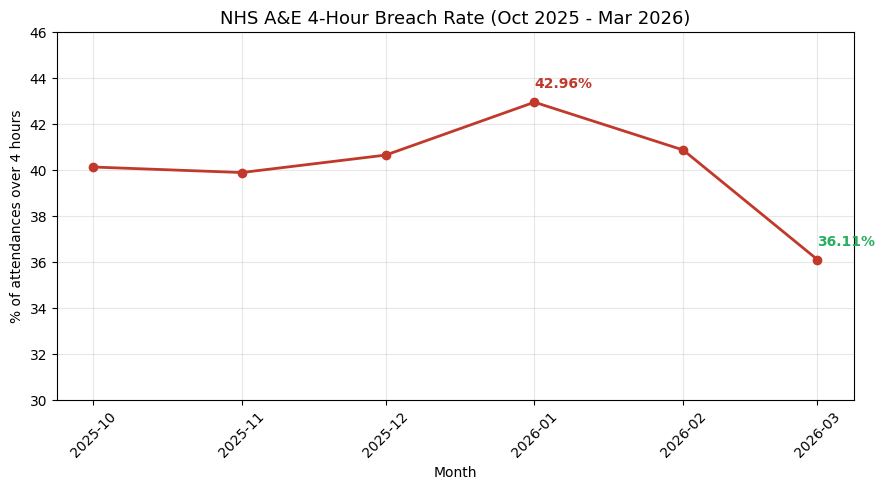

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.plot(monthly_summary_v2.index, monthly_summary_v2["breach_rate_%"], marker='o', linewidth=2, color='#c0392b')
plt.title("NHS A&E 4-Hour Breach Rate (Oct 2025 - Mar 2026)", fontsize=13)
plt.xlabel("Month")
plt.ylabel("% of attendances over 4 hours")
plt.ylim(30, 46)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Annotate the peak and lowest points so the finding is visually obvious
peak = monthly_summary_v2["breach_rate_%"].idxmax()
low = monthly_summary_v2["breach_rate_%"].idxmin()
plt.annotate(f'{monthly_summary_v2.loc[peak, "breach_rate_%"]}%', xy=(peak, monthly_summary_v2.loc[peak, "breach_rate_%"]),
             xytext=(0,10), textcoords='offset points', fontweight='bold', color='#c0392b')
plt.annotate(f'{monthly_summary_v2.loc[low, "breach_rate_%"]}%', xy=(low, monthly_summary_v2.loc[low, "breach_rate_%"]),
             xytext=(0,10), textcoords='offset points', fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.savefig("finding1_breach_rate_trend.png", dpi=150)
plt.show()

In [12]:
# Finding 2: Which trusts have the worst 12+ hour waits, and how has this changed over the period?
long_wait_col = "Patients who have waited 12+ hrs from DTA to admission"

# National trend for 12+ hr waits
monthly_12hr = cleaned_v2.groupby("month_year")[long_wait_col].sum()
print("National 12+ hr waits by month:")
print(monthly_12hr)

# Worst trusts overall (summed across all 6 months)
trust_totals = cleaned_v2.groupby("Org name")[long_wait_col].sum().sort_values(ascending=False)
print("\nTop 10 worst trusts for 12+ hr waits (total across 6 months):")
print(trust_totals.head(10))

# As a % of their emergency admissions, to normalize for trust size
trust_admissions = cleaned_v2.groupby("Org name")["Emergency admissions via A&E - Type 1"].sum()
trust_rate = (trust_totals / trust_admissions.replace(0, pd.NA) * 100).sort_values(ascending=False)
print("\nTop 10 worst trusts by 12+ hr wait RATE (% of emergency admissions):")
print(trust_rate.head(10).round(2))

National 12+ hr waits by month:
month_year
2025-10-01    54326
2025-11-01    50648
2025-12-01    50789
2026-01-01    71517
2026-02-01    54649
2026-03-01    46665
Name: Patients who have waited 12+ hrs from DTA to admission, dtype: int64

Top 10 worst trusts for 12+ hr waits (total across 6 months):
Org name
ROYAL FREE LONDON NHS FOUNDATION TRUST                  12244
UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST    10511
THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST            8641
NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST              7370
EAST LANCASHIRE HOSPITALS NHS TRUST                      7246
UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST         7232
BARTS HEALTH NHS TRUST                                   7159
LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION TRUST      6956
PORTSMOUTH HOSPITALS UNIVERSITY NHS TRUST                6889
EAST KENT HOSPITALS UNIVERSITY NHS FOUNDATION TRUST      6859
Name: Patients who have waited 12+ hrs from DTA to admission, dtype: i

## Finding 2: Raw Counts Mislead — Normalize by Size

By raw count, the worst-performing trusts for 12+ hour waits are simply the biggest
trusts (Royal Free London, Birmingham) — unsurprising given their volume. But when
normalized as a % of emergency admissions, a different trust dominates: Croydon
Health Services, where 62.8% of emergency admissions waited 12+ hours — nearly
2 in 3 patients.

**Why it matters:** If resource allocation is based on raw totals, Croydon would be
overlooked entirely despite having the worst actual patient experience. This is a
clear case where the "obvious" metric (total count) hides the real story.

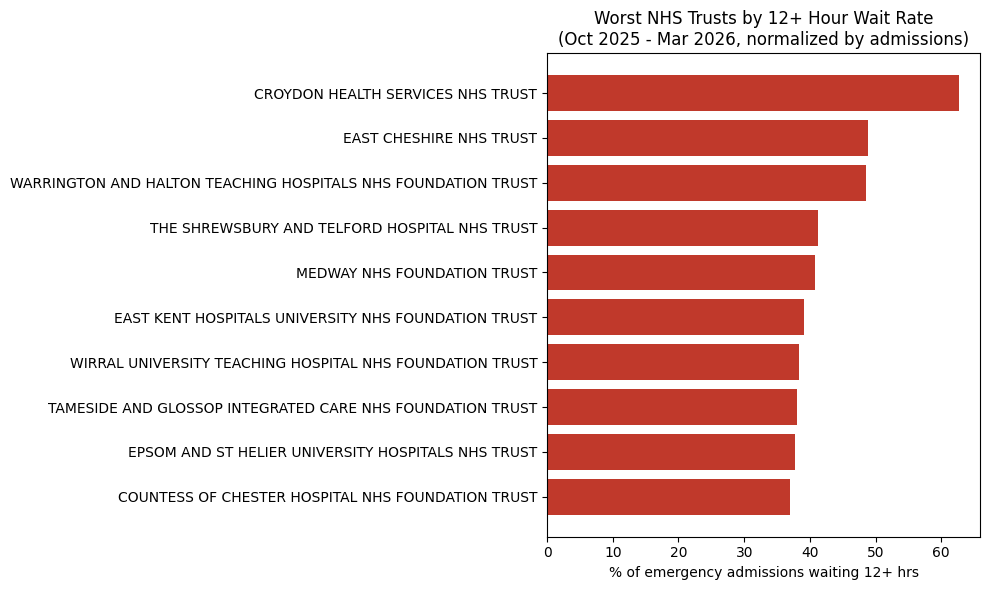

In [13]:
import matplotlib.pyplot as plt

top10_rate = trust_rate.head(10)

plt.figure(figsize=(10,6))
bars = plt.barh(top10_rate.index[::-1], top10_rate.values[::-1], color='#c0392b')
plt.xlabel("% of emergency admissions waiting 12+ hrs")
plt.title("Worst NHS Trusts by 12+ Hour Wait Rate\n(Oct 2025 - Mar 2026, normalized by admissions)")
plt.tight_layout()
plt.savefig("finding2_12hr_wait_rate.png", dpi=150)
plt.show()

In [14]:
# Finding 3: Does trust SIZE (attendance volume) correlate with breach rate?
trust_summary = cleaned_v2.groupby("Org name").agg(
    total_attendances=("A&E attendances Type 1", "sum"),
    total_over4hrs=("Attendances over 4hrs Type 1", "sum")
)
# Only look at trusts with meaningful A&E volume (exclude tiny walk-in centres)
trust_summary = trust_summary[trust_summary["total_attendances"] > 5000]
trust_summary["breach_rate"] = (trust_summary["total_over4hrs"] / trust_summary["total_attendances"] * 100)

correlation = trust_summary["total_attendances"].corr(trust_summary["breach_rate"])
print(f"Correlation between attendance volume and breach rate: {correlation:.3f}")

print("\nBiggest trusts by volume, with their breach rate:")
print(trust_summary.sort_values("total_attendances", ascending=False)[["total_attendances", "breach_rate"]].head(10).round(1))

print("\nSmallest trusts (>5000 attendances), with their breach rate:")
print(trust_summary.sort_values("total_attendances", ascending=True)[["total_attendances", "breach_rate"]].head(10).round(1))

Correlation between attendance volume and breach rate: -0.083

Biggest trusts by volume, with their breach rate:
                                                    total_attendances  \
Org name                                                                
UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION ...             204306   
MID AND SOUTH ESSEX NHS FOUNDATION TRUST                       162244   
UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST               161572   
ROYAL FREE LONDON NHS FOUNDATION TRUST                         160557   
MANCHESTER UNIVERSITY NHS FOUNDATION TRUST                     159529   
NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST                    157535   
BARTS HEALTH NHS TRUST                                         154378   
FRIMLEY HEALTH NHS FOUNDATION TRUST                            136821   
UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST                    135603   
CHELSEA AND WESTMINSTER HOSPITAL NHS FOUNDATION...             119930   

          

## Finding 3: Trust Size Doesn't Predict Performance

There is effectively no correlation (r = -0.083) between attendance volume and breach
rate. Some of the largest trusts (Birmingham: 204K attendances) perform near-average,
while both the best (Sheffield Children's: 8.5% breach rate) and worst (North Tees:
55.2%) performers are similarly-sized smaller trusts.

**Why it matters:** This challenges the common assumption that bigger hospitals
struggle more due to volume. Performance appears driven by other factors — staffing,
local demand patterns, operational efficiency — not sheer size. Worth investigating
which specific factors actually predict performance, if I had more time.

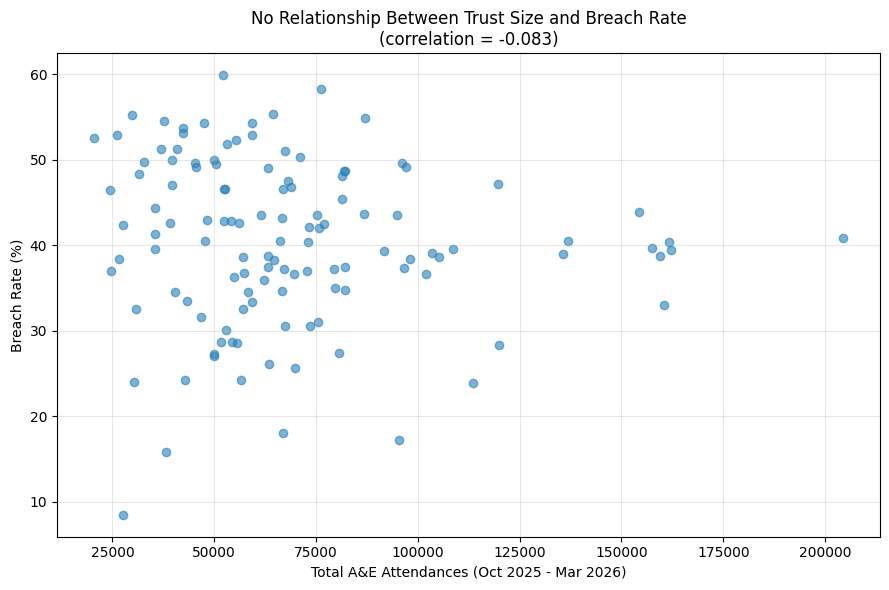

In [15]:
plt.figure(figsize=(9,6))
plt.scatter(trust_summary["total_attendances"], trust_summary["breach_rate"], alpha=0.6, color='#2980b9')
plt.xlabel("Total A&E Attendances (Oct 2025 - Mar 2026)")
plt.ylabel("Breach Rate (%)")
plt.title(f"No Relationship Between Trust Size and Breach Rate\n(correlation = {correlation:.3f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("finding3_size_vs_breach.png", dpi=150)
plt.show()